In [223]:
import numpy as np
from scipy.stats import norm
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt

In [224]:
S = 100         #current price
K = 100         #strike 
T = 1           #time to expiry
r = 0.05        #risk free rate
sigma = 0.2     #volatility

**Black-Scholes**

In [225]:
def black_scholes(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


bs = black_scholes(S,K,T,r,sigma)
print(bs)

10.450583572185565


**Monte-Carlo**

In [228]:
def monte_carlo(S, K, T, r, sigma, N): 
    Z = np.random.normal(0, 1, N)                   #create N random numbers
    S_T = S * np.exp((r - sigma**2/2)*T + sigma*np.sqrt(T)*Z)           #simulate N different random stock price paths
    payoff = np.maximum(S_T-K, 0)                           #calculate payoff for each path
    price = np.exp(-r*T)*np.mean(payoff)                    #price = averages the payoffs and discounts using the risk free rate
    return price

mc = np.zeros(6)
N = []
error = []
for i in range(6):    
    mc[i] = monte_carlo(S,K,T,r,sigma,100*(5**i))
    N.append(100*(5**i))
    error.append(abs(mc[i]-bs)/bs * 100)
    print(f"N={100*5**i}: {mc[i]}     error: {abs(mc[i]-bs)/bs * 100}%")

N=100: 9.74231380734067     error: 6.777322624642404%
N=500: 10.847614779878636     error: 3.7991295409548056%
N=2500: 10.620062546080495     error: 1.621717799051934%
N=12500: 10.527855213734782     error: 0.7394002546889051%
N=62500: 10.478363175251909     error: 0.2658186777270521%
N=312500: 10.452253189729284     error: 0.015976309190643582%


**Error vs N Plots** 

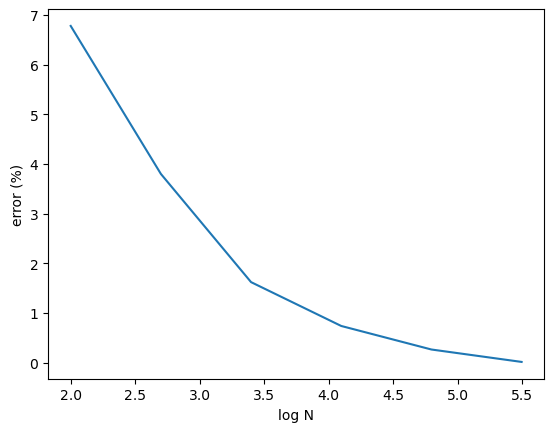

In [229]:
plt.plot(np.log10(N),error)
plt.ylabel('error (%)')
plt.xlabel('log N')
plt.show()

**Finite Difference Method** <br>
∂V/∂t + ½σ²S² ∂²V/∂S² + rS ∂V/∂S − rV = 0

Discretised using Crank Nicolson:<br>
−a_i·V[j+1][i-1] + (1−b_i)·V[j+1][i] − c_i·V[j+1][i] = a_i·V[j][i-1] + (1+b_i)·V[j][i] + c_i·V[j][i+1]<br>
- a_i = dt/4(sigma^2 * i^2 − ri)
- b_i = -dt/2(sigma^2 * i^2 + r)
- c_i = dt/4(sigma^2 * i^2 + ri)

In [194]:
def fin_diff(S, K, T, r, sigma, ds, dt, S_max):    
    
    
    s = np.arange(0,S_max+ds,ds)
    Ns = len(s)
    tau = np.arange(0,T+dt,dt)          #tau = T-t, this is so that we can start the method from t = T at expiry and work backwards
    Nt = len(tau)

    V = np.zeros((int(Nt), int(Ns)))        #create empty matrix for finding V

    V[:,-1] = S_max - K*np.exp(-r*(tau))        #implements boundary condition (0s in column 0 already there for other boundary condition), calculated as stock price minus the present value of the strike
    V[0,:] = np.maximum(0,s-K)


    
    A = np.zeros((Ns-2,Ns-2))       #A*u = B    (B is a known vector and u is an unknowns vector)
    B = np.zeros(Ns-2)       

    for j in range(1,Nt):       #iterate over each time step starting at tau = 0 (t = T)
        a = (dt/4)*(sigma**2  - r)
        b = -(dt/2)*(sigma**2 + r)
        c = (dt/4)*(sigma**2  + r)
        A[0][0] = 1 - b
        A[0][1] = -c
        B[0] = np.dot(np.array([a,1+b,c]),V[j-1,:3])  + a * V[j,0]          #do first step manually because boundary condition is involved

        for i in range(2,Ns-2):     #loop over each position in the row to create a set of linear equations
            a = (dt/4)*(sigma**2 * i**2 - r*i)
            b = -(dt/2)*(sigma**2 * i**2 + r)
            c = (dt/4)*(sigma**2 * i**2 + r*i)

            A[i-1][i-2] = -a
            A[i-1][i-1] = 1-b
            A[i-1][i] = -c              #insert A matrix coefficients

            B[i-1] = np.dot(np.array([a,1+b,c]), V[j-1, i-1:i+2])       #update B

        a = (dt/4)*(sigma**2 * (Ns-2)**2 - r*(Ns-2))
        b = -(dt/2)*(sigma**2 * (Ns-2)**2 + r)
        c = (dt/4)*(sigma**2 * (Ns-2)**2 + r*(Ns-2))    


        A[-1][-1] = 1 -b
        A[-1][-2] = -a
        B[-1] = np.dot(np.array([a,1+b,c]),V[j-1,-3:])  + c * V[j,-1]           #do final step manually because boundary condition is involved

        A_banded = np.zeros((3,Ns-2))          #created banded matrix so solve_banded can be used O(m) instead of O(m**3)
        A_banded[0,1:] = np.diag(A, 1)    # super-diagonal
        A_banded[1,:]  = np.diag(A, 0)    # main diagonal
        A_banded[2,:-1] = np.diag(A, -1)  # sub-diagonal
        V[j,1:-1] = solve_banded((1,1), A_banded, B)        #solve_banded allows much more efficient solving because it doesn't look at all the empty zeros in the A matrix

    price = V[-1][int(round(S/ds))]
   
    return price

ds = [10,5,2,1,0.5]
dt = [0.5,0.25,0.1,0.05,0.025]
for i in range(5):    
    fd = fin_diff(S,K,T, r,sigma, ds=ds[i], dt=dt[i], S_max=1000)
    print(f"ds, dt - {ds[i]}, {dt[i]}: {fd}     error: {abs(fd-bs)/bs * 100}%")




ds, dt - 10, 0.5: 10.173585966531594     error: 2.6505467732080126%
ds, dt - 5, 0.25: 10.343363146575134     error: 1.0259754861517936%
ds, dt - 2, 0.1: 10.416641384958726     error: 0.3247874818892983%
ds, dt - 1, 0.05: 10.435293825853194     error: 0.1463051917317334%
ds, dt - 0.5, 0.025: 10.443379575074223     error: 0.0689339218387301%


**Method Comparison**

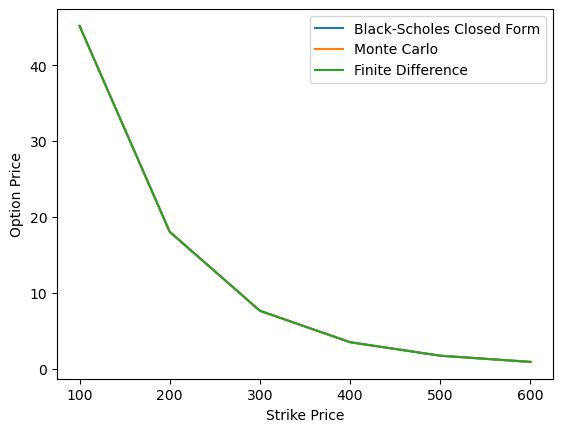

In [200]:
S = 100         
     
T = 10     
r = 0.05      
sigma = 0.2

bs_price = []
mc_price = []
fd_price = []

for i in range(6):
    K = (i+1)*100
    bs_price.append(black_scholes(S, K, T, r, sigma))
    mc_price.append(monte_carlo(S, K, T, r, sigma, N = 20000000))
    fd_price.append(fin_diff(S, K, T, r, sigma, ds=0.5 ,dt=0.01 ,S_max=1000))

strike = np.arange(100,700,100)

plt.plot(strike, bs_price, label='Black-Scholes Closed Form')
plt.plot(strike, mc_price, label='Monte Carlo')
plt.plot(strike, fd_price, label='Finite Difference')
plt.legend()
plt.ylabel('Option Price')
plt.xlabel('Strike Price')
plt.show()